# **SI 313 WN26: Experiment Module Assignment**
##### Nick Pisarczyk - Wednesday, 04/15/26<br>uniqname: npisar<br> 
---

### Overview
You will design a complete experiment to test a change to a digital interface — the kind of work UX researchers and product teams do routinely at companies like Google, Meta, and Spotify. Unlike Kramer et al.'s (2014) Facebook study, which ran on nearly 700,000 users without their knowledge, you'll think carefully about how to run an ethical, well-powered experiment from scratch.

You won't collect real data. You'll design the experiment, simulate a small dataset, and analyze it. The goal is to practice the full arc of running an experiment: from research questions to results and ethical reflection.

---

### Part 1 and 2:
https://docs.google.com/document/d/1_KOzLOg2RINzoEVlHytHmUP2zquM1b0tuDhP5UoPwbc/edit?usp=sharing

---

# **Part 3: Simulate and Analyze Data**
In Python, simulate a realistic dataset for your experiment and run the appropriate statistical test. Include your code and outputs in a Jupyter Notebook file (.ipynb). Include your write-up with visualizations in the PDF file.

Required steps:
- Simulate 200 participants (100 per condition) with plausible outcome values for your context. Set a random seed for reproducibility.
- Create a visualization comparing the two conditions for each outcome variable.
- Run an independent sample t-test for each outcome variable.
- Report and interpret: the test statistic, p-value, and Cohen's d effect size.
- In 2–3 sentences, distinguish between statistical significance and practical importance for your results. Would an effect of this size matter in the real world?

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Randomization / Sample Simulation

In [ ]:
# Random seed
np.random.seed(16395)

# Create the groups
group_size = 100
n = 2 * group_size
assignments = 8

students = pd.DataFrame({
    "student_id": np.arange(2*group_size),
    "condition": ["control"] * group_size + ["reminder"] * group_size
})

condition = np.array(["control"] * group_size + ["reminder"] * group_size)
df_long = students.loc[students.index.repeat(assignments)].copy()
df_long["assignment_id"] = df_long.groupby("student_id").cumcount()





"""
Simulate assignment turn-in outcomes

### Assumptions:
- Each student has 8 eligible assignments during the experiment window.
    - Therefore there can be 0 to 8 on-time submissions

Control: ~73% of assignments submitted on-time
Treatment: ~87% of assignments submitted on-time
"""
control_rate = 0.73
reminder_rate = 0.87

p = np.where(df_long["condition"].values == "control", control_rate, reminder_rate)
df_long["on_time"] = np.random.binomial(1, p, size=len(df_long))





"""
Simulate average "Time-distance" for all eight assignments, per student (hours before the deadline when first engagement happens)

### Assumptions
- Many students engage late; reminders might help make them engage earlier.
- Some students never engage, resulting in the default value of time_distance = 0.
- Otherwise, engagement time follows a right-skewed distribution
    - Lognormal: lower bound of zero, and long tail to right.
        - Most students don't start assignments super early, so right skew makes sense here
        - Don't want any negative values -- that would mean they started before the assignment was posted
    - Capped at 168 hours (7 days) to avoid crazy outliers


### Details
- Student x assignment level (df_long: one row per assignment, per student).
- For each row, set specific parameters:
    - never_p: probability student never engages with assignment (time_distance = 0)
    - mu, sigma: lognormal parameters for when student does engage
- Get a random number x for each row:
    - If x < never_p, they never engaged. Time distance = 0
    - Otherwise, get a random time_distance, using Lognormal(mean=mu, sigma=sigma)
- All simulated time_distance values capped at 168 hours (7 days) to avoid huge outliers.


### Lognormal params:
- Median is e^μ - so:
    - control_mu = 2.3 = e^2.3 = ~10h
    - reminder_mu = 2.8 = e^2.8 = ~16.4h
- Sigma is the spread
    - With μ = 2.8, sigma = 0.85:
        - Lower “one-sigma” bound: e^(2.8 - 0.85)  =  e^1.95  =  ~7.0h  
        - Upper “one-sigma” bound: e^(2.8 + 0.85)  =  e^3.65  =  ~38.5h
Never Engage Groups
- Control: more of "never engage" group + later overall engagement
- Reminder: fewer of "never engage" group + earlier overall engagement
"""
never_engage_control, never_engage_reminder = 0.18, 0.10
control_mu, control_sigma = 2.3, 0.8
reminder_mu, reminder_sigma = 2.8, 0.85

never_p = np.where(df_long["condition"].values == "control", never_engage_control, never_engage_reminder)
mu = np.where(df_long["condition"].values == "control", control_mu, reminder_mu)
sigma = np.where(df_long["condition"].values == "control", control_sigma, reminder_sigma)

x = np.random.rand(len(df_long))
time_distance = np.zeros(len(df_long))

engage_mask = x >= never_p
time_distance[engage_mask] = np.random.lognormal(mean=mu[engage_mask], sigma=sigma[engage_mask])
time_distance = np.minimum(time_distance, 168)  # cap at 7 days

df_long["time_distance_hours"] = time_distance
# print(f"df_long {df_long}")





"""
### Aggregate the data

Each student's data (based on their student id) is aggregated:
- sum of all on-time assignments
- mean of all time distance values
"""
df = (df_long
      .groupby(["student_id", "condition"], as_index=False)
      .agg(on_time_count=("on_time", "sum"),
           avg_time_distance_hours=("time_distance_hours", "mean"))
     )
print(f"Created sample dataset!")

Created sample dataset!


In [3]:
# Preview and groupby to glance at data
print(f"Data Head:\n{df.head(20)}")
print(f"\n")
df.groupby("condition")[["on_time_count","avg_time_distance_hours"]].describe()

Data Head:
    student_id condition  on_time_count  avg_time_distance_hours
0            0   control              4                11.779425
1            1   control              6                 9.536758
2            2   control              5                14.005517
3            3   control              7                 4.757216
4            4   control              7                 9.130927
5            5   control              5                11.667868
6            6   control              4                 7.111855
7            7   control              6                 9.139554
8            8   control              7                 6.350292
9            9   control              6                 8.298450
10          10   control              7                15.964179
11          11   control              5                14.569145
12          12   control              6                 8.947326
13          13   control              4                10.139078
14          14

on_time_count                                           \
                  count  mean       std  min  25%  50%  75%  max   
condition                                                          
control           100.0  5.94  1.196122  3.0  5.0  6.0  7.0  8.0   
reminder          100.0  6.93  1.066051  4.0  6.0  7.0  8.0  8.0   

          avg_time_distance_hours                                            \
                            count       mean       std       min        25%   
condition                                                                     
control                     100.0  10.945011  4.248698  2.890070   7.984629   
reminder                    100.0  20.590966  8.945094  5.144889  14.509406   

                                            
                 50%        75%        max  
condition                                   
control    10.222264  13.287064  25.916242  
reminder   19.598069  24.830985  62.778544

---

## Visualizations

In [4]:
sns.set_style("whitegrid")

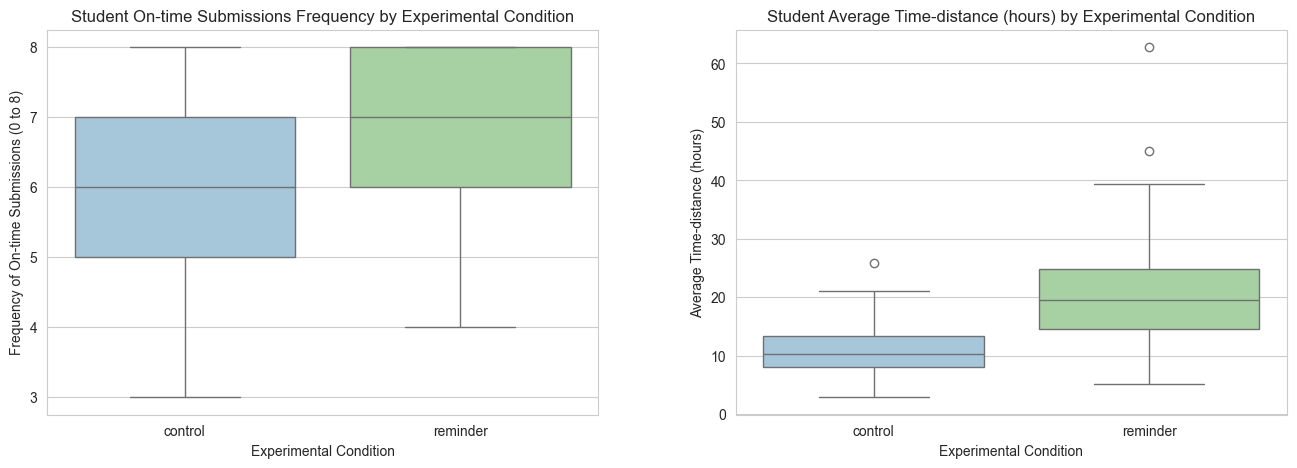

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# On-time submission count (0-8)
sns.boxplot(data=df, x="condition", y="on_time_count", ax=axes[0], hue="condition", legend=False, palette=["#9ecae1","#a1d99b"])
axes[0].set_title("Student On-time Submissions Frequency by Experimental Condition")
axes[0].set_xlabel("Experimental Condition")
axes[0].set_ylabel("Frequency of On-time Submissions (0 to 8)")

# Average Time-distance (hours)
sns.boxplot(data=df, x="condition", y="avg_time_distance_hours", ax=axes[1], hue="condition", legend=False, palette=["#9ecae1","#a1d99b"])
axes[1].set_title("Student Average Time-distance (hours) by Experimental Condition")
axes[1].set_xlabel("Experimental Condition")
axes[1].set_ylabel("Average Time-distance (hours)")

plt.subplots_adjust(wspace = 0.25)
plt.show()

---

## Independent Samples T-Test

In [6]:
# cohens d helper function
def cohens_d(control, reminder):
    """
    Cohen's d for two independent groups using pooled SD.
    Returns d where positive means mean(y) > mean(x).
    """
    control = np.asarray(control); reminder = np.asarray(reminder)
    n_control, n_reminder = control.size, reminder.size
    sample_var_control, sample_var_reminder = control.var(ddof=1), reminder.var(ddof=1)
    pooled = np.sqrt(((n_control - 1) * sample_var_control + (n_reminder - 1) * sample_var_reminder) / (n_control + n_reminder - 2))
    return (reminder.mean() - control.mean()) / pooled

# t and d helper function
def t_and_d(control_group, reminder_group, column):
    t = stats.ttest_ind(reminder_group[column], control_group[column], equal_var=True)
    d = cohens_d(control_group[column], reminder_group[column])
    return t, d

# Split up the groups
control_group = df[df["condition"] == "control"]
reminder_group = df[df["condition"] == "reminder"]

# Outcome 1: On-time submissions (count out of 8)
# Outcome 2: Avg time-distance across 8 assignments (hours)
t1, d1 = t_and_d(control_group, reminder_group, "on_time_count")
t2, d2 = t_and_d(control_group, reminder_group, "avg_time_distance_hours")

print(f"statistical tests run successfully!")

statistical tests run successfully!


In [7]:
# t / d output
print("1. On-time submissions (count out of 8)")
print(f"    Control mean = {control_group['on_time_count'].mean():.2f} | Reminder mean = {reminder_group['on_time_count'].mean():.2f}")
print(f"    t(198) = {t1.statistic:.3f} | p = {t1.pvalue:.4f}*** | Cohen's d = {d1:.3f}\n")

print("2. Avg time-distance (hours) across 8 assignments")
print(f"    Control mean = {control_group['avg_time_distance_hours'].mean():.2f} | Reminder mean = {reminder_group['avg_time_distance_hours'].mean():.2f}")
print(f"    t(198) = {t2.statistic:.3f} | p = {t2.pvalue:.4f}*** | Cohen's d = {d2:.3f}")

1. On-time submissions (count out of 8)
    Control mean = 5.94 | Reminder mean = 6.93
    t(198) = 6.179 | p = 0.0000*** | Cohen's d = 0.874

2. Avg time-distance (hours) across 8 assignments
    Control mean = 10.95 | Reminder mean = 20.59
    t(198) = 9.741 | p = 0.0000*** | Cohen's d = 1.378


## Analysis

### Frequency of on-time submissions:<br>
Students in the reminder condition had a higher mean on-time submission count than students in the control condition. Students in the control condition turned in $5.94 / 8$ assignments on time, on average, and students in the reminder condition turned in $6.93 / 8$ assignments on time, on average. An independent-samples t-test found $t(198) = 6.179, p < 0.0001$, with Cohen’s $d = 0.874$ (large). The tiny p-value and large t-test statistic indicate that chances of observing the differences in this sample by chance are effectively zero, and the large Cohen's d indicates a large effect size; there is a difference between these two groups very likely specifically because of the treatment.
<br><br><br>

### Average time-distance:<br>
Students in the reminder condition exhibited a larger average time-distance (hours before the deadline when they first opened the assignment, averaged for all 8 assignments) than the students in the control condition. An independent samples t-test found $t(198) = 9.741, p < 0.0001$, with a Cohen’s $d = 1.37$ (large). The tiny p-value and large t-test statistic indicate that chances of observing the differences in this sample by chance are effectively zero, and the large Cohen's d indicates a large effect size; there is a difference between these two groups very likely specifically because of the treatment.
<br><br><br>

### Statistical significance vs practical importance:<br>
Statistical significance in this experiment indicates the obsevered increase of ~1.0 on time submissions and ~10h larger time distance are extremely unlikely to be the result of random chance ($p < 0.0001$). Practically, this means the effect of the reminder treatment is very meaningful; the extra on-time submission could significantly impact a student's grade, and having a 10h head start on assignments on average highly reduces the risk of technical issues when submitting, students staying up extra late to get assignments turned in, and may reduce stress-induced errors in their work.

---

# **Part 4: Ethical Review**

## Informed Consent and IRB
This experiment would require IRB review; it uses a treatment that has potential to impact the academic performance of real human subject students. In a real-world application of this experiment, students might not realize they're a part of an experiment, unless it's specifically disclosed to them through the syllabus, or they're asked to opt-in. For this reason, for this experiment, we would require and informed consent waiver from every student participating.
This is very different from the approach in Kramer, et al.'s Facebook "emotional contagion" study (2014). In this study, the research team manipulated the Facebook feeds of hundreds of thousands of users without their knowledge or consent. This caused a lot of controversy and conversation around transparency and informed consent for users in digital experiments like these, which is much of the reason for the approach taken towards informed consent with this experiment.
<br><br><br>

## Potential Harms
One ethical concern is that the control group might have lowered academic success compared to students in the reminder group by withholding giving these students helpful reminder notifications. Alternatively, the reminder group might experience fatigue or anxiety from the new notification system. These notifications might be overwhelming and cause students to become more anxious about assignments than they otherwise would be if the reminders are considered too frequent by some students. Or, it might cause some students to be fatigued and stop paying attention to notifications from the course altogether, and miss notifications they would have seen otherwise.
<br><br><br>

## External Validity
By looking at University of Michigan students enrolled in courses with graded assignments that have clear deadlines and that must be directly submitted through Canvas we can pretty reliably generalize these results to other students at universities that use digital platforms like Canvas for assignment submission. There are some features of this population that limit the generalizability of this research, though. For one, many high schools and intermediate schools use Learning Management Systems (LMS) like Canvas, Blackboard, Google Classroom, etc., but since the contexts and demands of these levels of education are so different, it might not be valid to generalize the results past university students. Additionally, these results cannot be generalized to courses that do the majority of their assignments as physical hand-ins without Canvas assignments, as well as any courses that use external submission/grading tools like gradescope. This can be generalized for Unviersity of Michigan and other university courses that primarily use LMS for their work, but not much past that. 
<br><br><br>

## Heterogeneity of Treament Effects
One subgroup that the treatment effect might differ for is extremely organized / "type A" students. While chronic procrastinators or at-risk students that struggle with time management theoretically could see the biggest benefit from the treatment, these "type-A" students might already have their schedule down, their Canvas assignments in their Google Calendar with automated reminders set up, etc. These reminders could acutally negatively effect their UX if they're receiving notifcations from four different channels for every assignment. I would investigate this by pairing the treatment with students' prior submission history and GPA (obtained with their consent through the unviersity) to see if any patterns emerge for this group. Understanding this matters because we could get more insight on how different types of students might actually want to use these reminders, and what customization options there would need to be if they were to be actually implemented on the site. 

---

# **AI Appendix**

- I used AI as a starting point for multiple parts of this project. I had no idea how to create a random sample of participants, so I used AI to create that the initial verison of that part of the assignemnt. I learned a lot about numpy, found a lognormal disrtubution that worked well for my case... AI was very helpful here in helping me actually get started with the rest of the code.
    - On that note, I had never used random seeds or anything like that before. Used AI to get started with it, asked AI for help understanding what was going on with it, and generally learned a lot about this type of workflow by using the AI's initial output.
- In my initial prompt about generating this randomization stuff, I fed the AI all of my Part 1/Part 2 writeup so it had context for my experiment. Then, I said:<br>
    "Please answer this:<br>
    """<br>
    Part 3: Simulate and Analyze Data<br>
    In Python, simulate a realistic dataset for your experiment and run the appropriate statistical test. Include your code and outputs in a Jupyter Notebook file (.ipynb). Include your write-up with visualizations in the PDF file.<br><br>
    Required steps:
    - Simulate 200 participants (100 per condition) with plausible outcome values for your context. Set a random seed for reproducibility.
    - Create a visualization comparing the two conditions for each outcome variable.
    - Run an independent sample t-test for each outcome variable.
    - Report and interpret: the test statistic, p-value, and Cohen's d effect size.
    - In 2–3 sentences, distinguish between statistical significance and practical importance for your results. Would an effect of this size matter in the real world?<br>
    """<br>
    "

- Like previous projects, I used AI to help me with the graphing parts; it's just so much faster than I am, and I'm able to get a graph from AI and adjust axis labels, make sure everything is fit to the parameters of the project, etc.

- Much of the code for the statistical testing was initially created using AI, but I edited the syntax quite a bit to fit my needs. I changed many variable names to make the code understandable, reworked some of the code to use my own helper function, and generally reorganized and reformatted much of what AI gave me in order to actually understand what was going on in these statistical tests.
    - I spent a lot of time sitting down reading through what the AI gave me to make sure I actually understood it. Then, I was able to edit the code to fit my needs and to be better formatted for my uses.

- I also asked multiple questions about what things in the functions meant. I asked about lognormal distrbutions, what mu / sigma values are, what a large sigma means, asked it to explain the Cohen's d function step by step... etc.
    - Prompt examples:
        - explain the cohens d function please step by step
        - mu_control, sigma_control = 2.3, 0.8mu_reminder, sigma_reminder = 2.8, 0.85. what does this mean / what is a lognormal distribution
        - Is 0.85 a big sigma
        - etc.

- I used AI to brainstorm some ideas for Part 1 of the assignment -- in terms of the outcomes I could measure. I also drafted the Treatment Delivery process with AI to make sure I wasn't missing anything in my methods section. I used AI during Part 1 and Part 2 to help get started.
    - I honestly just gave UM-GPT the assignment piece by piece to see what it gave me. I asked clarifying questions from the results to understand that content, and also asked for writing help with some of my prompts. For example:
        - please give me 4 options for the name of [mechanism I was prompting about]
            - come up with some more like procrastination interruption; words that mean getting rid of procrastination, stopping it, quelling it, etc.
        - Is my second measure appropriate? Why?
        - etc.

I used AI on this assignment, but the majority of the assignment came from me sitting down and doing it, with AI in the background available when I needed it.